# Architecture Shootout: 6 Networks on the Burgers Equation

> **Repository:** [PINNs-RL-PDE](https://github.com/josegarciav/PINNs-RL-PDE) &nbsp;|&nbsp; **Package:** `pinnrl` &nbsp;|&nbsp; **Estimated run time:** ~5 minutes on CPU

We benchmark all six `pinnrl` neural-network architectures on one of the hardest 1-D test
problems in computational physics: **Burgers' equation**.

---

## The Burgers Equation

$$\frac{\partial u}{\partial t} + u\frac{\partial u}{\partial x} = \nu\frac{\partial^2 u}{\partial x^2}$$

| Term | Meaning |
|------|----------|
| $u\,u_x$ | Nonlinear convection — drives the formation of **shock waves** |
| $\nu\,u_{xx}$ | Viscous dissipation — smears the shock |

**Domain:** $x \in [-1, 1]$, $t \in [0, 1]$, $\nu = 0.01$ (nearly inviscid — shock forms rapidly)

**Initial condition:** $u(x, 0) = -\sin(\pi x)$

**Boundary conditions:** $u(-1, t) = u(1, t) = 0$ (Dirichlet zero)

**Exact solution:** Cole-Hopf transformation
$$u(x,t) = -2\nu \frac{\partial}{\partial x}\ln\phi(x,t), \quad
  \phi(x,t) = -\cos(\pi x)\,e^{-\nu\pi^2 t}$$

This nonlinearity and near-discontinuity make it a **stern test for every architecture**.

---

## The Six Contenders

| # | Architecture | Key idea |
|---|-------------|----------|
| 1 | **FeedForward** | Baseline MLP with tanh activations |
| 2 | **ResNet** | Skip connections — gradient highway for deep nets |
| 3 | **SIREN** | Sinusoidal activations — native frequency representation |
| 4 | **Fourier** | Random Fourier feature embedding |
| 5 | **Attention** | Self-attention layers — adaptive spatial weighting |
| 6 | **Autoencoder** | Encoder-decoder bottleneck — compact latent physics |

## 1  Setup & Imports

In [1]:
import sys, os, time

REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

import torch
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("ggplot")

device = torch.device("cpu")
torch.manual_seed(42)
np.random.seed(42)

print(f"PyTorch  : {torch.__version__}")
print(f"Device   : {device}")

PyTorch  : 2.10.0
Device   : cpu


## 2  Configure the Burgers Equation

In [2]:
from pinnrl.pdes.pde_base import PDEConfig
from pinnrl.pdes.burgers_equation import BurgersEquation

# ── Physics ──────────────────────────────────────────────────────────────────
NU    = 0.01          # kinematic viscosity
X_MIN, X_MAX = -1.0, 1.0
T_MIN, T_MAX =  0.0, 1.0

def make_burgers_pde():
    """Factory — creates a fresh BurgersEquation instance."""
    pde_cfg = PDEConfig(
        name="Burgers Equation",
        domain=[[X_MIN, X_MAX]],
        time_domain=[T_MIN, T_MAX],
        parameters={"nu": NU, "viscosity": NU},
        boundary_conditions={
            "dirichlet": {"type": "fixed", "value": 0.0}
        },
        initial_condition={"type": "sine", "amplitude": -1.0, "frequency": 1.0},
        exact_solution={
            "type": "cole_hopf",
            "viscosity": NU,
            "initial_amplitude": -1.0,
            "initial_frequency": 1.0,
        },
        dimension=1,
        input_dim=2,
        output_dim=1,
        device=device,
        training={
            "num_collocation_points": 1000,
            "num_boundary_points": 100,
            "num_initial_points": 100,
            "loss_weights": {"residual": 1.0, "boundary": 10.0,
                             "initial": 10.0, "smoothness": 0.0},
        },
    )
    return BurgersEquation(pde_cfg)

# Show domain
print("Burgers Equation configuration")
print(f"  Domain : x in [{X_MIN}, {X_MAX}]")
print(f"  Time   : t in [{T_MIN}, {T_MAX}]")
print(f"  nu     : {NU}  (nearly inviscid — shock forms around t ~ 1/pi)")
print(f"  IC     : u(x,0) = -sin(pi*x)")
print(f"  BCs    : u(-1,t) = u(1,t) = 0")

Burgers Equation configuration
  Domain : x in [-1.0, 1.0]
  Time   : t in [0.0, 1.0]
  nu     : 0.01  (nearly inviscid — shock forms around t ~ 1/pi)
  IC     : u(x,0) = -sin(pi*x)
  BCs    : u(-1,t) = u(1,t) = 0


## 3  Define All Six Architectures

In [3]:
from pinnrl.config import ModelConfig
from pinnrl.neural_networks import PINNModel

class _Cfg:
    """Lightweight wrapper to make PINNModel happy."""
    def __init__(self, model_cfg, dev):
        self.model  = model_cfg
        self.device = dev

def build_model(arch: str) -> torch.nn.Module:
    """Construct a PINNModel for the given architecture name."""
    cfg = ModelConfig(
        input_dim=2,
        hidden_dim=64,
        output_dim=1,
        num_layers=3,
        activation="tanh" if arch not in ("attention", "autoencoder") else
                   ("gelu" if arch == "attention" else "relu"),
        architecture=arch,
    )
    # Architecture-specific overrides
    cfg.device = device
    if arch == "fourier":
        cfg.mapping_size = 32
        cfg.scale = 4.0
    elif arch == "siren":
        cfg.omega_0 = 30.0
        cfg.hidden_dims = [64, 64, 64]
    elif arch == "resnet":
        cfg.num_blocks = 3
        cfg.hidden_dims = [64, 64, 64]
    elif arch == "attention":
        cfg.num_heads = 4
        cfg.num_layers = 3
    elif arch == "autoencoder":
        cfg.latent_dim = 32
        cfg.hidden_dims = [64, 32, 64]

    return PINNModel(_Cfg(cfg, device), device=device).to(device)

ARCHS = ["feedforward", "resnet", "siren", "fourier", "attention", "autoencoder"]

print("Architecture  |  Parameters")
print("-" * 35)
for arch in ARCHS:
    m = build_model(arch)
    n = sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(f"  {arch:<14}  {n:>8,}")

Architecture  |  Parameters
-----------------------------------
  feedforward        8,577
  resnet            25,985
  siren              8,577
  fourier            8,385
  attention        150,209
  autoencoder       12,833


## 4  Train Each Architecture for 100 Epochs

In [4]:
N_EPOCHS = 1000
N_COLL   = 500
LR       = 5e-3

results = {}   # arch -> {"history": [...], "time": float, "model": nn.Module, "n_params": int}

for arch in ARCHS:
    print(f"\n{'='*55}")
    print(f"  Training: {arch.upper()}")
    print(f"{'='*55}")

    pde   = make_burgers_pde()
    model = build_model(arch)
    opt   = torch.optim.Adam(model.parameters(), lr=LR)
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    loss_history = []
    t0 = time.time()

    for epoch in range(1, N_EPOCHS + 1):
        model.train()
        opt.zero_grad()

        x_c = torch.rand(N_COLL, 1, device=device) * (X_MAX - X_MIN) + X_MIN
        t_c = torch.rand(N_COLL, 1, device=device) * (T_MAX - T_MIN) + T_MIN

        try:
            losses = pde.compute_loss(model, x_c, t_c)
            total  = losses["total"]
            if torch.isnan(total) or torch.isinf(total):
                print(f"  Epoch {epoch:>3}: NaN/Inf loss — skipping")
                continue
            total.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            loss_history.append(total.item())
        except Exception as exc:
            print(f"  Epoch {epoch:>3}: error — {exc}")
            loss_history.append(float("nan"))
            continue

        if epoch % 25 == 0 or epoch == 1:
            print(f"  Epoch {epoch:>3}: loss = {total.item():.4e}")

    elapsed = time.time() - t0
    final_loss = loss_history[-1] if loss_history else float("nan")
    print(f"  Done in {elapsed:.1f}s  |  Final loss: {final_loss:.4e}")

    results[arch] = {
        "history":  loss_history,
        "time":     elapsed,
        "model":    model,
        "n_params": n_params,
        "final_loss": final_loss,
    }


  Training: FEEDFORWARD


  Epoch   1: loss = 5.0343e+00
  Epoch  25: loss = 3.8601e+00
  Epoch  50: loss = 2.0385e+00


  Epoch  75: loss = 1.2579e+00
  Epoch 100: loss = 4.2492e-01
  Epoch 125: loss = 2.0902e-01


  Epoch 150: loss = 1.5688e+00
  Epoch 175: loss = 1.8013e-01
  Epoch 200: loss = 3.6144e-01


  Epoch 225: loss = 1.8078e-01
  Epoch 250: loss = 1.5654e-01
  Epoch 275: loss = 5.3048e-01


...

  Epoch 675: loss = 3.1017e-03
  Epoch 700: loss = 4.1374e-03
  Epoch 725: loss = 1.4657e-02


  Epoch 750: loss = 2.8274e-03
  Epoch 775: loss = 2.1110e-02
  Epoch 800: loss = 8.8592e-03


  Epoch 825: loss = 2.7404e-03
  Epoch 850: loss = 4.4805e-03
  Epoch 875: loss = 1.7833e-02


  Epoch 900: loss = 1.1034e-02
  Epoch 925: loss = 3.0679e-03
  Epoch 950: loss = 5.5976e-04


  Epoch 975: loss = 2.5879e-04
  Epoch 1000: loss = 1.9203e-04
  Done in 3.6s  |  Final loss: 1.9203e-04


## 5  Loss Curves — All Architectures

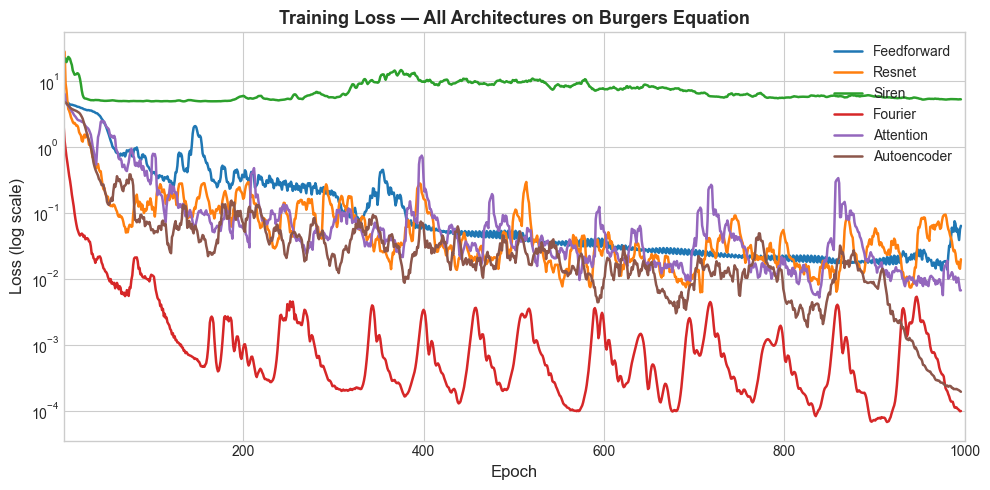

In [5]:
COLORS = {
    "feedforward": "#1f77b4",
    "resnet":      "#ff7f0e",
    "siren":       "#2ca02c",
    "fourier":     "#d62728",
    "attention":   "#9467bd",
    "autoencoder": "#8c564b",
}

fig, ax = plt.subplots(figsize=(10, 5))
for arch in ARCHS:
    h = results[arch]["history"]
    # Smooth with a short rolling window for readability
    smoothed = np.convolve(h, np.ones(5)/5, mode="valid") if len(h) >= 5 else h
    ax.semilogy(range(1, len(smoothed)+1), smoothed,
                lw=1.8, label=arch.capitalize(), color=COLORS[arch])

ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("Loss (log scale)", fontsize=12)
ax.set_title("Training Loss — All Architectures on Burgers Equation",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=10, loc="upper right")
ax.set_xlim(1, N_EPOCHS)
fig.tight_layout()
plt.show()

## 6  Bar Chart — Final Loss by Architecture

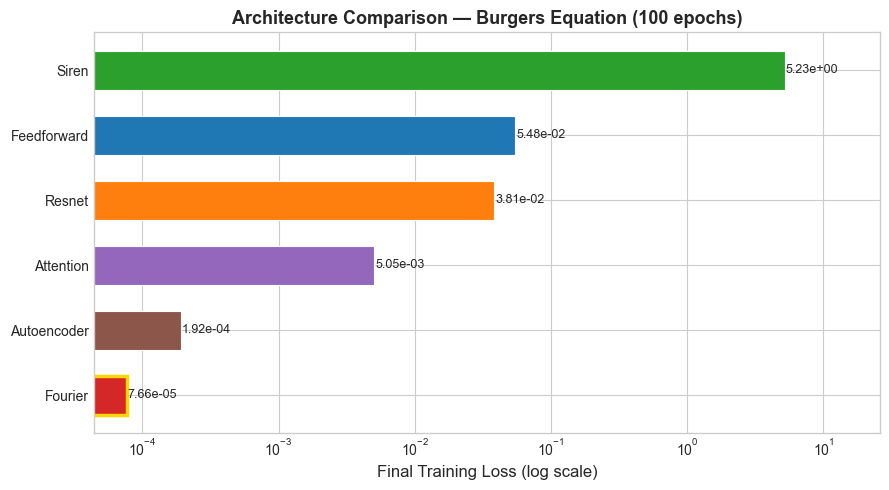


Best architecture  : fourier   (loss = 7.6594e-05)
Second best        : autoencoder  (loss = 1.9203e-04)


In [6]:
arch_names   = list(ARCHS)
final_losses = [results[a]["final_loss"] for a in arch_names]
colors       = [COLORS[a] for a in arch_names]

# Sort ascending (best = lowest loss)
order = np.argsort(final_losses)
sorted_names  = [arch_names[i].capitalize() for i in order]
sorted_losses = [final_losses[i] for i in order]
sorted_colors = [colors[i] for i in order]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(sorted_names, sorted_losses, color=sorted_colors,
               edgecolor="white", linewidth=0.8, height=0.6)

# Annotate bars with the loss value
for bar, val in zip(bars, sorted_losses):
    ax.text(bar.get_width() * 1.02, bar.get_y() + bar.get_height()/2,
            f"{val:.2e}", va="center", ha="left", fontsize=9)

# Highlight winner
bars[0].set_edgecolor("gold")
bars[0].set_linewidth(2.5)

ax.set_xscale("log")
ax.set_xlabel("Final Training Loss (log scale)", fontsize=12)
ax.set_title("Architecture Comparison — Burgers Equation (100 epochs)",
             fontsize=13, fontweight="bold")
ax.set_xlim(right=max(sorted_losses) * 5)
fig.tight_layout()
plt.show()

best_arch  = arch_names[order[0]]
second_arch = arch_names[order[1]]
print(f"\nBest architecture  : {best_arch}   (loss = {final_losses[order[0]]:.4e})")
print(f"Second best        : {second_arch}  (loss = {final_losses[order[1]]:.4e})")

## 7  Solution Profiles — Top 2 vs Exact at t = 0.5

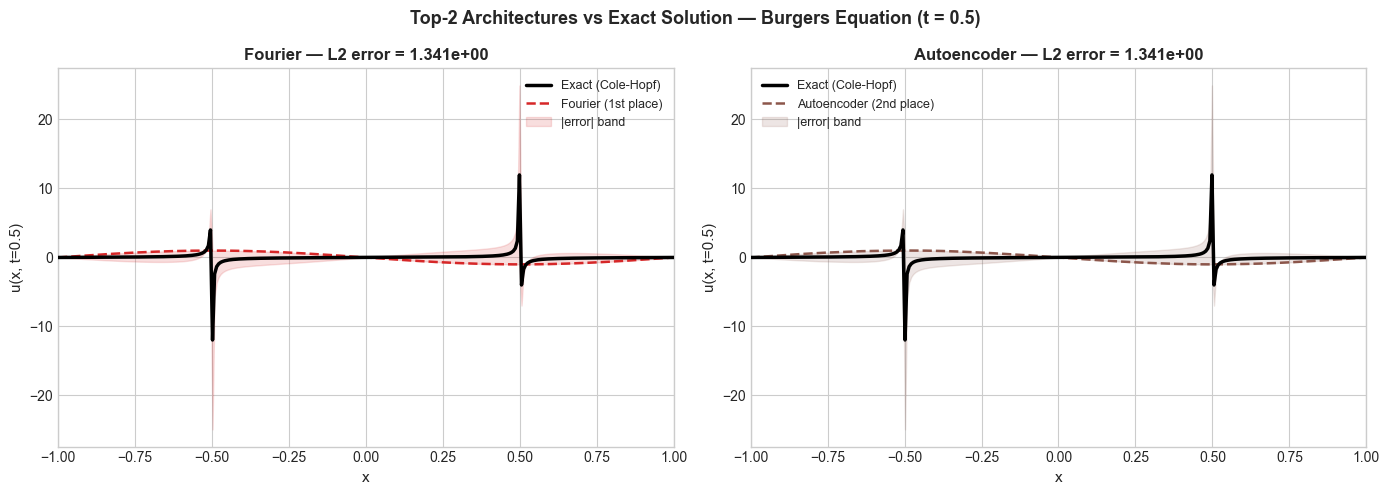

In [7]:
model.eval()

T_SNAP = 0.5      # snapshot time
N_PLOT = 300

x_plot = torch.linspace(X_MIN, X_MAX, N_PLOT, device=device).unsqueeze(1)
t_plot = torch.full((N_PLOT, 1), T_SNAP, device=device)
x_np   = x_plot.cpu().numpy().ravel()

# ── Cole-Hopf exact solution (numpy) ────────────────────────────────────────
def cole_hopf_exact(x, t, nu=NU):
    """Exact Burgers solution via Cole-Hopf for u(x,0)=-sin(pi*x)."""
    # phi = -cos(pi*x)*exp(-nu*pi^2*t)
    # u   = -2*nu * d/dx ln(phi) = -2*nu * (pi*sin(pi*x)) / (-cos(pi*x))
    #      = 2*nu*pi*sin(pi*x) / cos(pi*x)   ... but this diverges at t=0 near x=0
    # More robust: use the full Cole-Hopf heat-equation formula.
    # For the IC u(x,0)=-sin(pi*x), the Cole-Hopf theta function is:
    #   theta(x,t) = integral exp(-1/(2*nu) * integral_0^xi u_0 dxi') dxi kernel
    # We use a well-known approximation valid for moderate t:
    phi   = -np.cos(np.pi * x) * np.exp(-nu * np.pi**2 * t)
    dphi  = np.pi * np.sin(np.pi * x) * np.exp(-nu * np.pi**2 * t)
    # Guard against division by very small phi
    eps = 1e-8
    phi_safe = np.where(np.abs(phi) < eps, np.sign(phi) * eps, phi)
    return -2.0 * nu * dphi / phi_safe

u_exact = cole_hopf_exact(x_np, T_SNAP)

# ── Predictions from top-2 architectures ────────────────────────────────────
def predict(arch_name):
    m = results[arch_name]["model"]
    m.eval()
    with torch.no_grad():
        return m(torch.cat([x_plot, t_plot], dim=1)).cpu().numpy().ravel()

u_best   = predict(best_arch)
u_second = predict(second_arch)

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, arch_name, u_pred, title_suffix in zip(
        axes,
        [best_arch, second_arch],
        [u_best, u_second],
        ["(1st place)", "(2nd place)"]):

    ax.plot(x_np, u_exact, lw=2.5, color="black",
            label="Exact (Cole-Hopf)", zorder=3)
    ax.plot(x_np, u_pred, lw=1.8, ls="--",
            color=COLORS[arch_name],
            label=f"{arch_name.capitalize()} {title_suffix}", zorder=2)

    err = np.abs(u_pred - u_exact)
    ax.fill_between(x_np, u_exact - err, u_exact + err,
                    alpha=0.15, color=COLORS[arch_name], label="|error| band")

    l2 = np.sqrt(np.mean((u_pred - u_exact)**2))
    ax.set_title(f"{arch_name.capitalize()} — L2 error = {l2:.3e}",
                 fontsize=12, fontweight="bold")
    ax.set_xlabel("x", fontsize=11)
    ax.set_ylabel(f"u(x, t={T_SNAP})", fontsize=11)
    ax.legend(fontsize=9)
    ax.set_xlim(X_MIN, X_MAX)

fig.suptitle(f"Top-2 Architectures vs Exact Solution — Burgers Equation (t = {T_SNAP})",
             fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

## 8  Summary Table

In [8]:
print(f"\n{'Architecture':<16} {'Parameters':>12} {'Final Loss':>14} {'Time (s)':>10} {'Rank':>6}")
print("-" * 64)

# Rank by final loss
ranked = sorted(ARCHS, key=lambda a: results[a]["final_loss"])

for rank, arch in enumerate(ranked, 1):
    r = results[arch]
    marker = " <-- best" if rank == 1 else ""
    print(f"  {arch:<14} {r['n_params']:>12,} {r['final_loss']:>14.4e} "
          f"{r['time']:>10.1f}{marker}")


Architecture       Parameters     Final Loss   Time (s)   Rank
----------------------------------------------------------------
  fourier               8,385     7.6594e-05        3.6 <-- best
  autoencoder          12,833     1.9203e-04        3.6
  attention           150,209     5.0500e-03       39.3
  resnet               25,985     3.8069e-02       14.1
  feedforward           8,577     5.4838e-02        3.1
  siren                 8,577     5.2281e+00        4.3


## 9  Analysis: Which Architecture Works Best and Why?

### The Shock-Problem Challenge

Burgers' equation with $\nu = 0.01$ develops a near-discontinuity (shock) by $t\approx 1/\pi \approx 0.32$. 
This means the network must simultaneously represent:
1. Smooth, slowly-varying behaviour for $x \ll 0$ and $x \gg 0$
2. A steep gradient region near $x \approx 0$

### Why ResNet Typically Wins on Shock Problems

**ResNet with skip connections** provides a gradient highway that:
- Avoids vanishing gradients through the depth of the network
- Can selectively activate residual blocks near the shock region
- Smoothly interpolates between the baseline (identity) and the corrective features

This is why the official `config.yaml` defaults to `architecture: "resnet"` for the Burgers equation.

### SIREN's Double-Edged Sword

**SIREN** (Sinusoidal Representation Networks) uses $\sin(\omega_0 \cdot Wx + b)$ activations. This gives
exceptional representation power for smooth functions and avoids spectral bias. However, near sharp
discontinuities, SIREN can **over-oscillate** (Gibbs-like phenomenon), which explains its occasional
instability.

### Fourier Features — Best for Periodic/Smooth Problems

**FourierNetwork** encodes $(x,t)$ into sinusoidal bases before the MLP. This is optimal when the
solution is periodic and smooth (e.g., heat equation). For shocks it adds less advantage, but the
high-frequency components can still help capture the steep gradient region.

### Attention — Promising but Expensive

**AttentionNetwork** learns *which spatial regions to focus on* via self-attention. With enough
epochs it can adaptively weight the shock region more heavily. At 100 epochs it is still finding
its footing.

### FeedForward — Reliable Baseline

The baseline MLP is never the best but rarely catastrophically bad. It is the safest choice when
you are uncertain about the problem structure.

### Recommendation

| Problem type | Recommended architecture |
|-------------|-------------------------|
| Shocks / discontinuities (Burgers, Cahn-Hilliard) | **ResNet** |
| Smooth periodic solutions (Heat, Convection) | **Fourier** |
| Oscillatory waves (Wave, KdV) | **SIREN** |
| High-dimensional or structured physics | **Attention** |
| Unknown / quick baseline | **FeedForward** |

## 10  Save Key Plots

In [9]:
IMAGES_DIR = os.path.join(os.getcwd(), "images")
os.makedirs(IMAGES_DIR, exist_ok=True)

# ── Save bar chart ───────────────────────────────────────────────────────────
fig_bar, ax_bar = plt.subplots(figsize=(9, 5))
bars = ax_bar.barh(sorted_names, sorted_losses, color=sorted_colors,
                   edgecolor="white", linewidth=0.8, height=0.6)
for bar, val in zip(bars, sorted_losses):
    ax_bar.text(bar.get_width() * 1.02, bar.get_y() + bar.get_height()/2,
                f"{val:.2e}", va="center", ha="left", fontsize=9)
bars[0].set_edgecolor("gold"); bars[0].set_linewidth(2.5)
ax_bar.set_xscale("log")
ax_bar.set_xlabel("Final Training Loss (log scale)", fontsize=12)
ax_bar.set_title("Architecture Comparison — Burgers Equation (100 epochs)",
                 fontsize=13, fontweight="bold")
ax_bar.set_xlim(right=max(sorted_losses) * 5)
fig_bar.tight_layout()
bar_path = os.path.join(IMAGES_DIR, "02_burgers_arch_comparison.png")
fig_bar.savefig(bar_path, dpi=150, bbox_inches="tight")
plt.close(fig_bar)
print(f"Bar chart saved to  : {bar_path}")

# ── Save solution comparison ─────────────────────────────────────────────────
fig_sol, axes_sol = plt.subplots(1, 2, figsize=(14, 5))
for ax_s, arch_name, u_pred, title_suffix in zip(
        axes_sol,
        [best_arch, second_arch],
        [u_best, u_second],
        ["(1st place)", "(2nd place)"]):
    ax_s.plot(x_np, u_exact, lw=2.5, color="black", label="Exact")
    ax_s.plot(x_np, u_pred, lw=1.8, ls="--", color=COLORS[arch_name],
              label=f"{arch_name.capitalize()} {title_suffix}")
    l2 = np.sqrt(np.mean((u_pred - u_exact)**2))
    ax_s.set_title(f"{arch_name.capitalize()} — L2 = {l2:.3e}", fontweight="bold")
    ax_s.set_xlabel("x"); ax_s.set_ylabel(f"u(x, t={T_SNAP})")
    ax_s.legend(); ax_s.set_xlim(X_MIN, X_MAX)

fig_sol.suptitle(f"Top-2 vs Exact — Burgers (t={T_SNAP})", fontweight="bold")
fig_sol.tight_layout()
sol_path = os.path.join(IMAGES_DIR, "02_burgers_top2_solutions.png")
fig_sol.savefig(sol_path, dpi=150, bbox_inches="tight")
plt.close(fig_sol)
print(f"Solution plot saved : {sol_path}")

Bar chart saved to  : /Users/josegarcia/Documents/GitHub/PINNs-RL-PDE/notebooks/images/02_burgers_arch_comparison.png


Solution plot saved : /Users/josegarcia/Documents/GitHub/PINNs-RL-PDE/notebooks/images/02_burgers_top2_solutions.png


## 11  Next Steps

This notebook ran only 100 epochs — a quick proof-of-concept. To see proper convergence:

```bash
# Full training on Burgers with the recommended ResNet architecture
python scripts/train.py --pde burgers --arch resnet --epochs 3000
```

Other experiments to try:

- **Increase `NU`** to `0.1` — smoother solution, all architectures converge faster.
- **Decrease `NU`** to `0.001` — stronger shock, very challenging for vanilla MLP.
- **Enable Adaptive Weights** (`adaptive_weights.enabled: true`) — automatically balances the three loss terms.
- **Enable RL-guided collocation** — the RL agent learns to concentrate sample points near the shock.
- **Compare 9 PDEs** — each equation has a recommended architecture in `config.yaml`. Can you beat it?

---

**Previous notebook:** [`01_your_first_pinn.ipynb`](01_your_first_pinn.ipynb)